In [2]:
import sys, os

from common import optimizer

sys.path.append(os.pardir)

In [3]:
from dataset.mnist import load_mnist

In [4]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

x_train = x_train[:1000]
t_train = t_train[:1000]

from common.multi_layer_net import MultiLayerNet

In [5]:
from common.optimizer import SGD
optimizer = SGD(lr=0.01)

In [6]:
weight_decay_lambda = 0.1
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10, weight_decay_lambda=weight_decay_lambda)

In [7]:
max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []


In [8]:
iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

In [9]:
import numpy as np

In [10]:
for i in range(100000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        epoch_cnt += 1

        if epoch_cnt >= max_epochs:
            break

In [11]:
import matplotlib.pyplot as plt

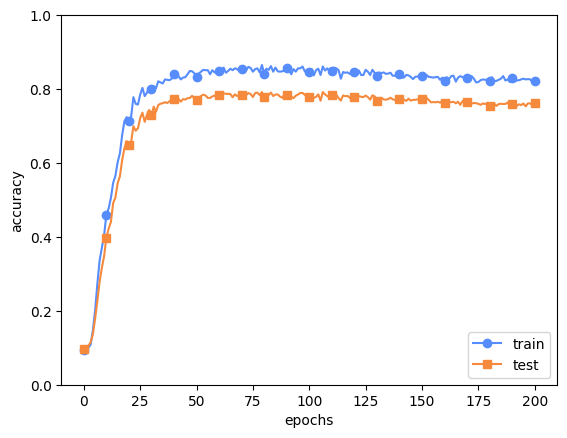

In [12]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()